In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    # a is already sigmoid(z), so this is the derivative w.r.t. z
    return a * (1 - a)

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([[0],[1],[1],[0]], dtype=float)

def init_weights(seed=None, zero_init=False):
    if zero_init:
        W1 = np.zeros((2,2)); b1 = np.zeros((1,2))
        W2 = np.zeros((2,1)); b2 = np.zeros((1,1))
    else:
        rng = np.random.RandomState(seed)
        W1 = rng.uniform(-1,1,(2,2)); b1 = np.zeros((1,2))
        W2 = rng.uniform(-1,1,(2,1)); b2 = np.zeros((1,1))
    return W1,b1,W2,b2

def forward(X, W1,b1,W2,b2):
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1,a1,z2,a2

def train_mlp(X, y, lr=1.0, epochs=6000, zero_init=False, log_every=200, seed=42):
    """
    Trains a 2-2-1 MLP with full-batch gradient descent.
    One 'update' = one full-batch gradient step (epoch), since backprop
    replaces the perceptron's single-sample update rule.
    Returns final params, a history list of (epoch, W1,b1,W2,b2, loss)
    logged every `log_every` epochs, and the full per-epoch loss list.
    """
    W1,b1,W2,b2 = init_weights(seed=seed, zero_init=zero_init)
    history = []
    losses = []

    _,_,_,a2 = forward(X,W1,b1,W2,b2)
    loss0 = np.mean((y-a2)**2)
    history.append((0, W1.copy(),b1.copy(),W2.copy(),b2.copy(), loss0))
    losses.append(loss0)

    for epoch in range(1, epochs+1):
        z1,a1,z2,a2 = forward(X,W1,b1,W2,b2)
        loss = np.mean((y-a2)**2)

        # Backpropagation (MSE loss, Sigmoid output)
        dA2 = (a2 - y)
        dZ2 = dA2 * sigmoid_deriv(a2)
        dW2 = a1.T @ dZ2 / X.shape[0]
        db2 = np.mean(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * sigmoid_deriv(a1)
        dW1 = X.T @ dZ1 / X.shape[0]
        db1 = np.mean(dZ1, axis=0, keepdims=True)

        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1

        losses.append(loss)
        if epoch % log_every == 0:
            history.append((epoch, W1.copy(),b1.copy(),W2.copy(),b2.copy(), loss))

    final_preds = forward(X,W1,b1,W2,b2)[3]
    return (W1,b1,W2,b2), history, losses, final_preds

In [11]:
params_rand, hist_rand, losses_rand, preds_rand = train_mlp(
    X, y, lr=1.0, epochs=6000, zero_init=False, log_every=200, seed=42
)

print("Final loss:", losses_rand[-1])
print("Final predictions:\n", np.round(preds_rand, 3))
print("Target:            \n", y)

Final loss: 0.00351016281411606
Final predictions:
 [[0.057]
 [0.936]
 [0.936]
 [0.051]]
Target:            
 [[0.]
 [1.]
 [1.]
 [0.]]


In [12]:
rows = []
for epoch, W1, b1, W2, b2, loss in hist_rand:
    rows.append({
        "Epoch": epoch,
        "Loss": round(float(loss), 5),
        "W1": np.round(W1, 3).tolist(),
        "b1": np.round(b1, 3).tolist(),
        "W2": np.round(W2, 3).tolist(),
        "b2": np.round(b2, 3).tolist(),
    })
df_rand = pd.DataFrame(rows)
df_rand  # one row per logged update (every 200 epochs), full weight matrices shown

,Epoch,Loss,W1,b1,W2,b2
0,0,0.28630,"[[-0.251, 0.901], [0.464, 0.197]]","[[0.0, 0.0]]","[[-0.688], [-0.688]]",[[0.0]]
1,200,0.25008,"[[-0.284, 0.843], [0.436, 0.048]]","[[-0.02, -0.074]]","[[-0.454], [-0.354]]",[[0.443]]
2,400,0.24999,"[[-0.287, 0.834], [0.448, -0.035]]","[[0.025, -0.073]]","[[-0.457], [-0.334]]",[[0.434]]
3,600,0.24991,"[[-0.297, 0.837], [0.467, -0.101]]","[[0.071, -0.059]]","[[-0.46], [-0.328]]",[[0.436]]
4,800,0.24983,"[[-0.314, 0.85], [0.495, -0.16]]","[[0.12, -0.035]]","[[-0.466], [-0.33]]",[[0.445]]
5,1000,0.24973,"[[-0.34, 0.872], [0.532, -0.218]]","[[0.174, 0.0]]","[[-0.476], [-0.341]]",[[0.465]]
6,1200,0.24955,"[[-0.38, 0.906], [0.585, -0.28]]","[[0.238, 0.049]]","[[-0.493], [-0.363]]",[[0.496]]
7,1400,0.24923,"[[-0.438, 0.958], [0.658, -0.353]]","[[0.315, 0.115]]","[[-0.521], [-0.398]]",[[0.546]]
8,1600,0.24857,"[[-0.525, 1.036], [0.767, -0.449]]","[[0.415, 0.207]]","[[-0.569], [-0.456]]",[[0.628]]
9,1800,0.24696,"[[-0.668, 1.163], [0.936, -0.59]]","[[0.551, 0.34]]","[[-0.657], [-0.554]]",[[0.769]]


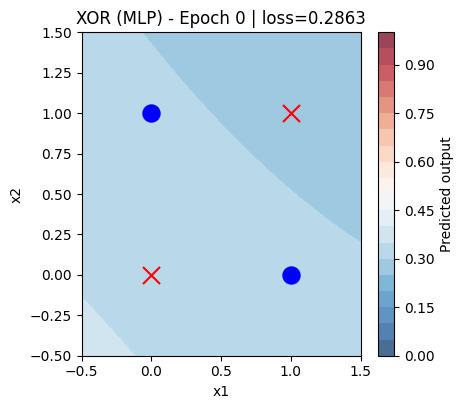

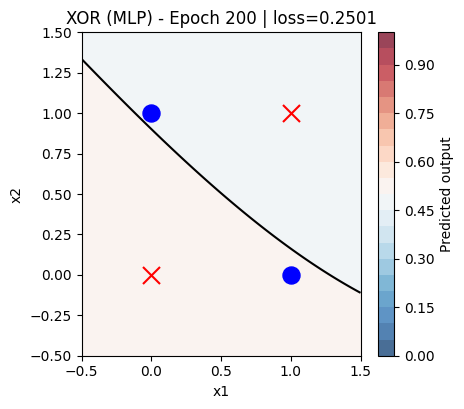

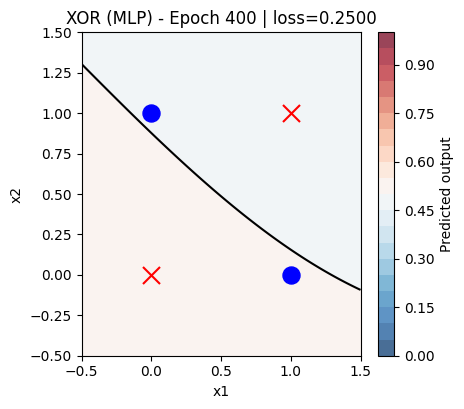

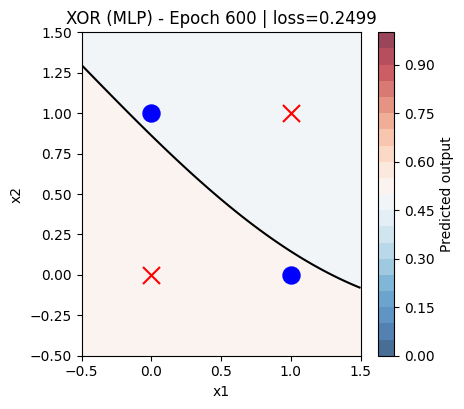

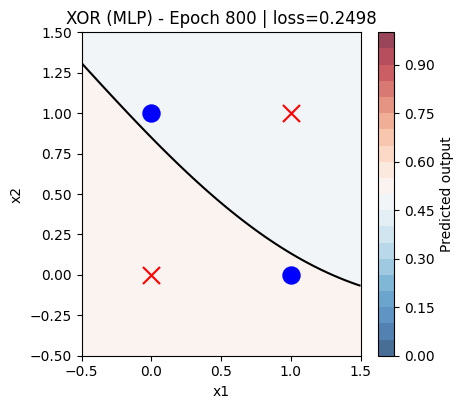

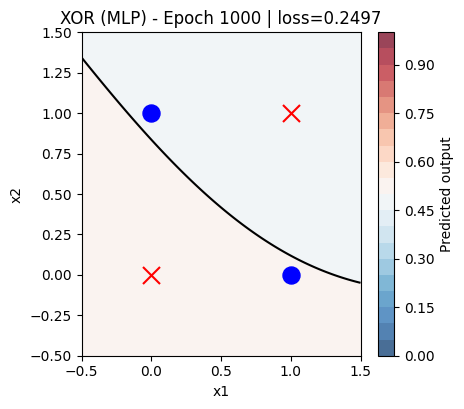

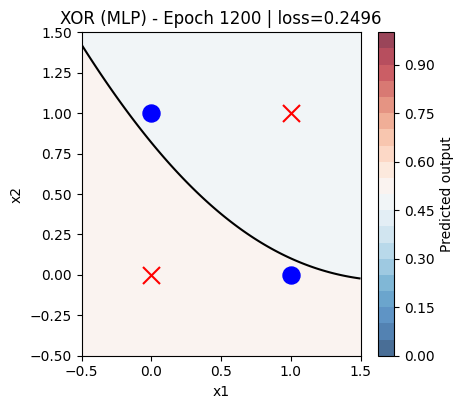

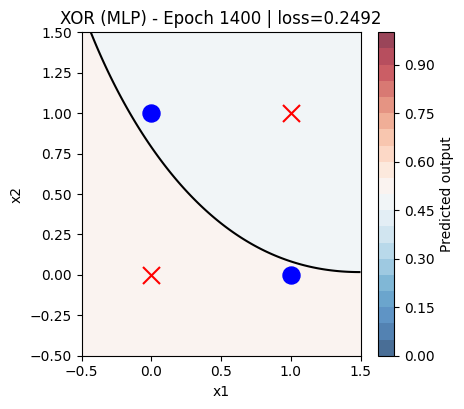

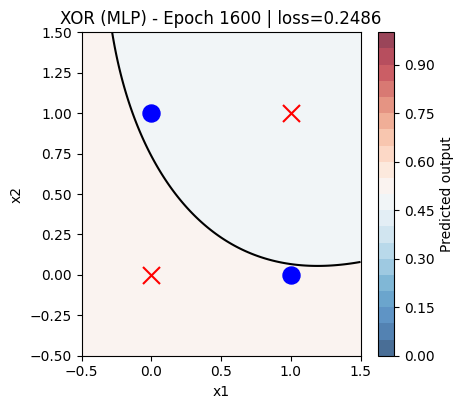

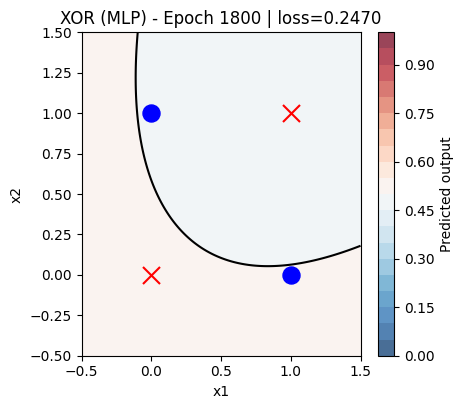

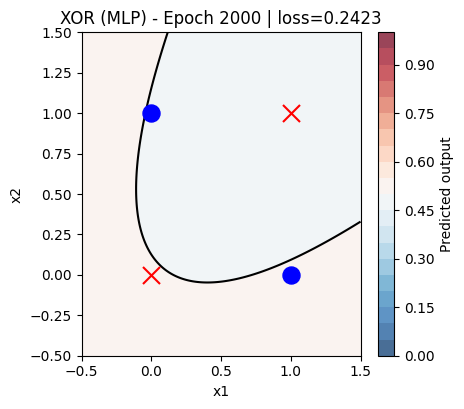

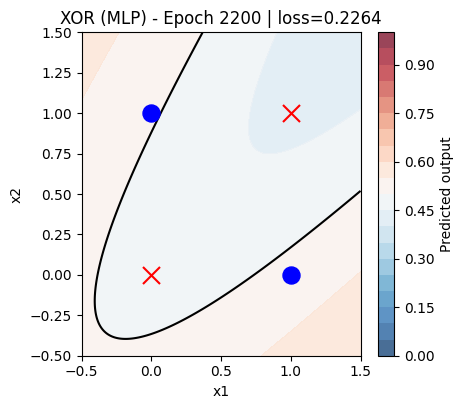

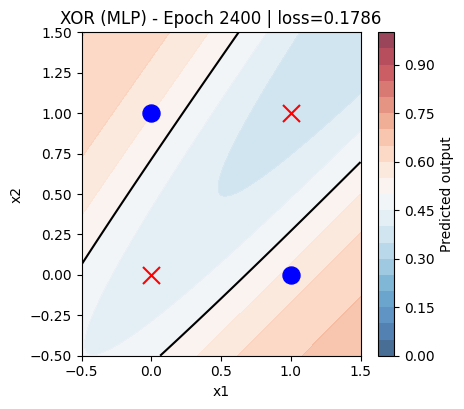

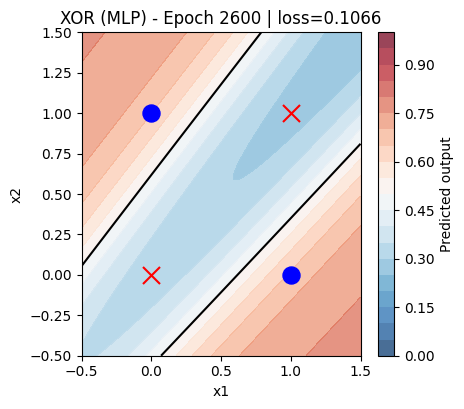

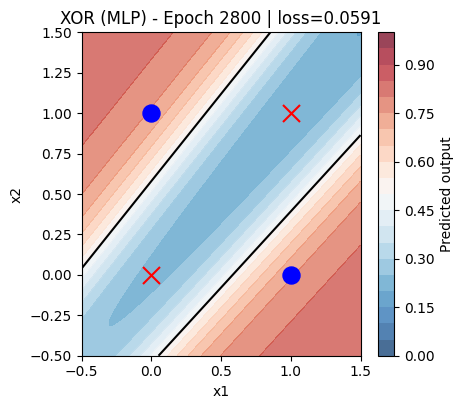

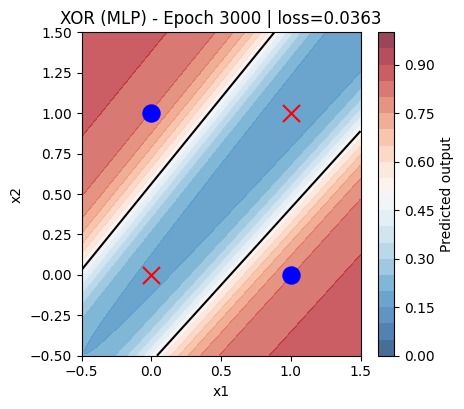

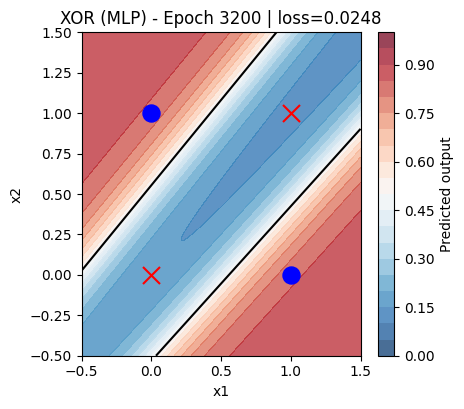

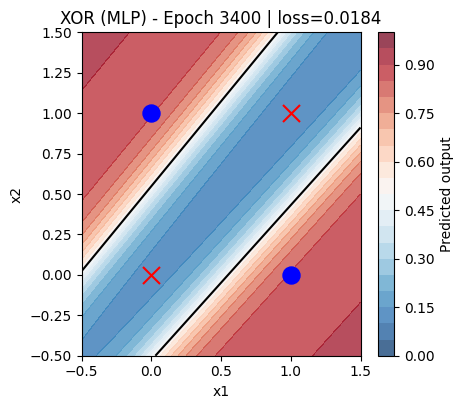

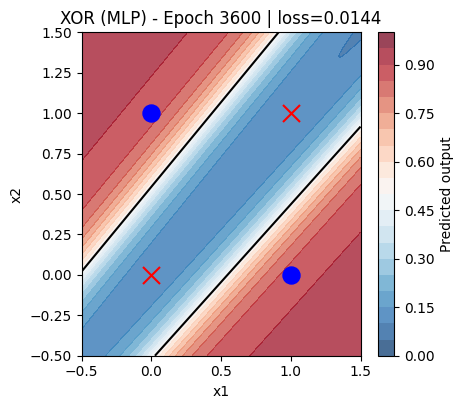

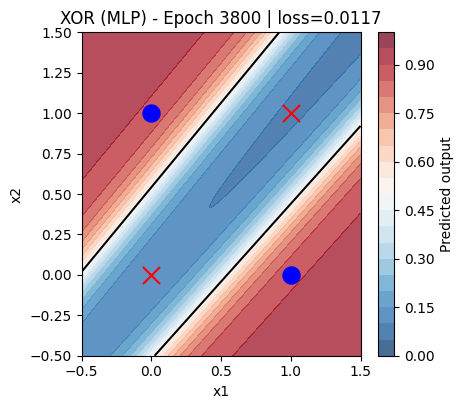

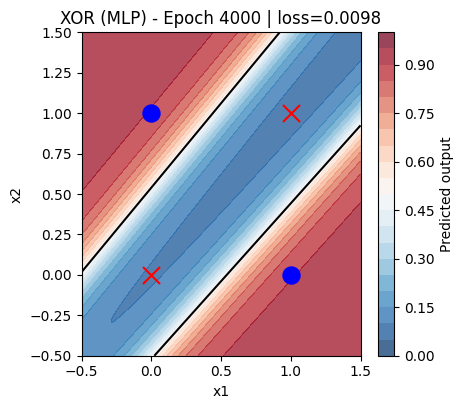

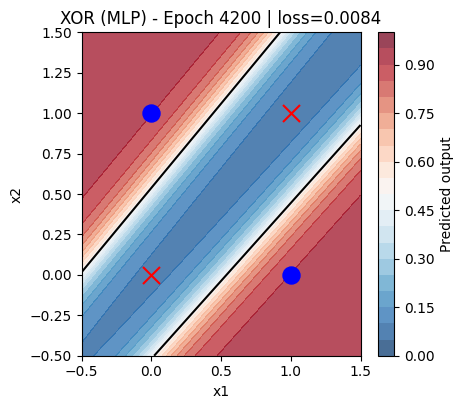

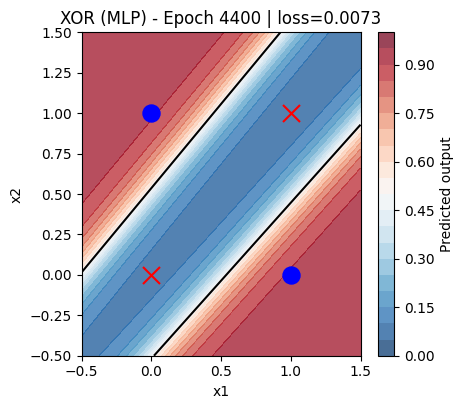

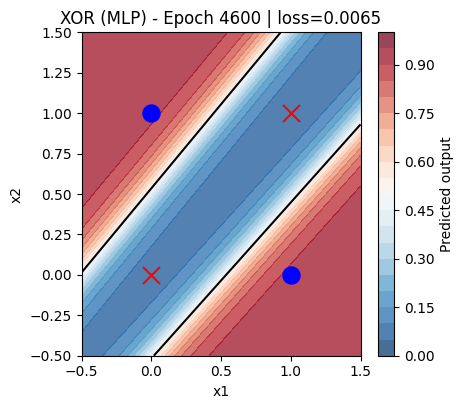

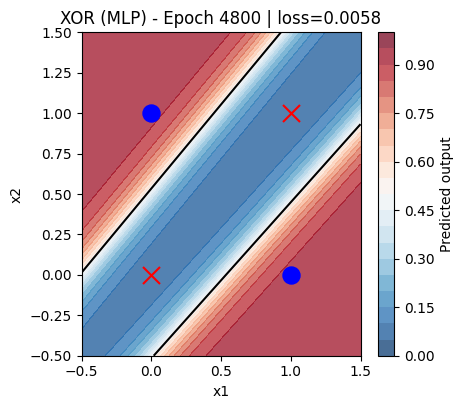

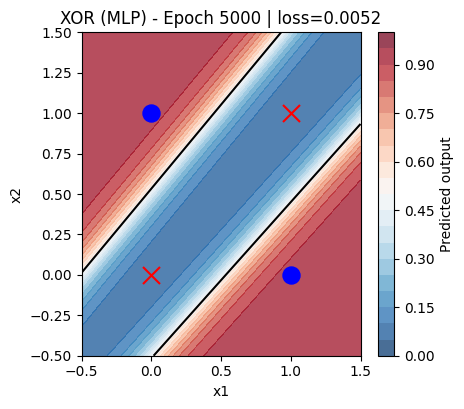

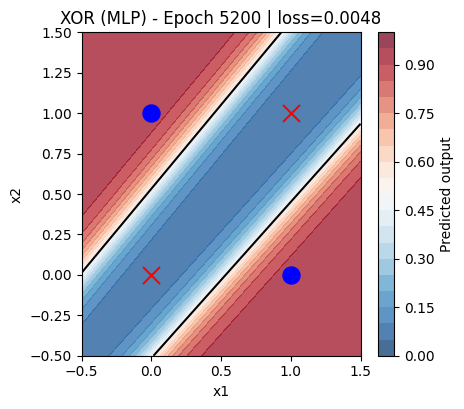

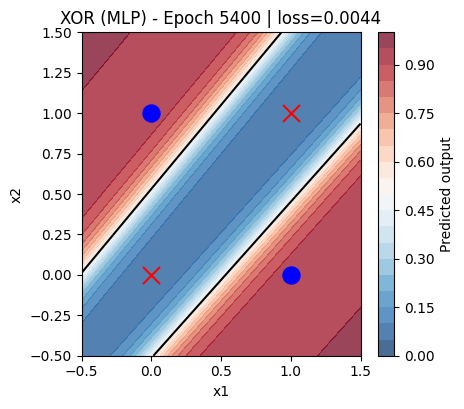

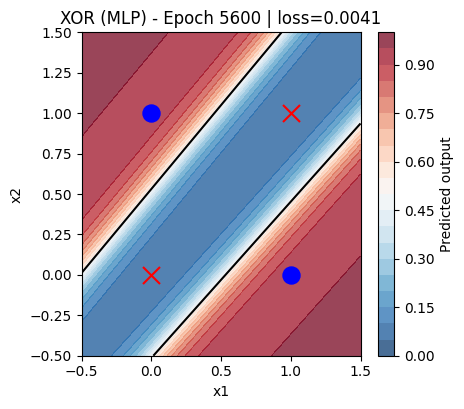

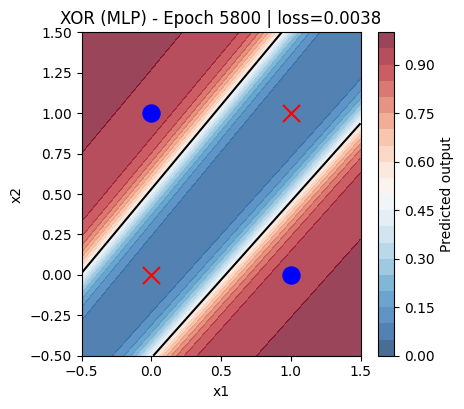

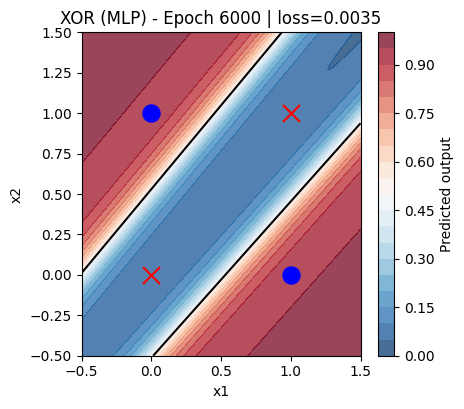

In [13]:
def plot_mlp_boundary(W1, b1, W2, b2, title):
    plt.figure(figsize=(4.5, 4.2))
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, _, _, a2 = forward(grid, W1, b1, W2, b2)
    zz = a2.reshape(xx.shape)

    cf = plt.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap='RdBu_r', alpha=0.75)
    plt.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)
    plt.colorbar(cf, label="Predicted output")

    for xi, target in zip(X, y.ravel()):
        color = 'blue' if target == 1 else 'red'
        marker = 'o' if target == 1 else 'x'
        plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150, zorder=5)

    plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(title)
    plt.show()

def plot_all_updates(history, gate_name="XOR (MLP)"):
    for epoch, W1, b1, W2, b2, loss in history:
        title = f"{gate_name} - Epoch {epoch} | loss={loss:.4f}"
        plot_mlp_boundary(W1, b1, W2, b2, title)

# Plots every logged snapshot (31 total, every 200 epochs) -- slice this if you want fewer
plot_all_updates(hist_rand)

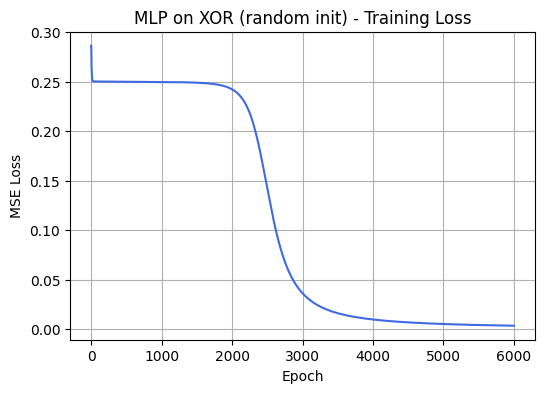

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(losses_rand, color='royalblue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP on XOR (random init) - Training Loss")
plt.grid(True)
plt.show()

In [15]:
params_zero, hist_zero, losses_zero, preds_zero = train_mlp(
    X, y, lr=1.0, epochs=6000, zero_init=True, log_every=200
)

print("Zero-init final loss:", losses_zero[-1])
print("Zero-init final predictions:\n", np.round(preds_zero, 3))
print("Zero-init final W1:\n", params_zero[0])
print("Zero-init final W2:\n", params_zero[2])

Zero-init final loss: 0.25
Zero-init final predictions:
 [[0.5]
 [0.5]
 [0.5]
 [0.5]]
Zero-init final W1:
 [[0. 0.]
 [0. 0.]]
Zero-init final W2:
 [[0.]
 [0.]]


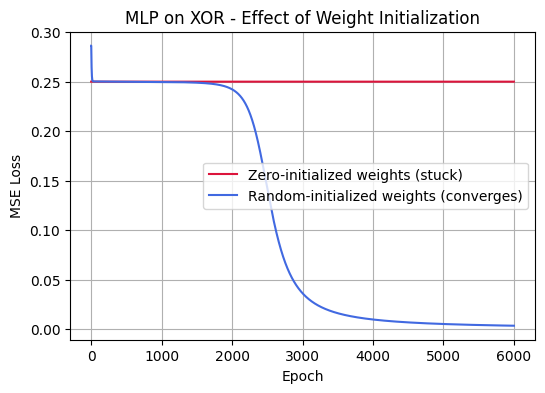

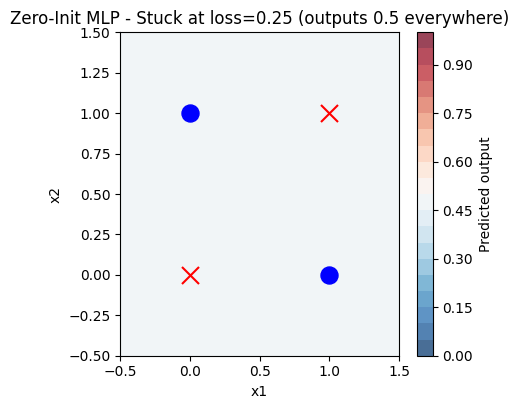

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(losses_zero, label="Zero-initialized weights (stuck)", color='crimson')
plt.plot(losses_rand, label="Random-initialized weights (converges)", color='royalblue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP on XOR - Effect of Weight Initialization")
plt.legend()
plt.grid(True)
plt.show()

plot_mlp_boundary(*params_zero, "Zero-Init MLP - Stuck at loss=0.25 (outputs 0.5 everywhere)")